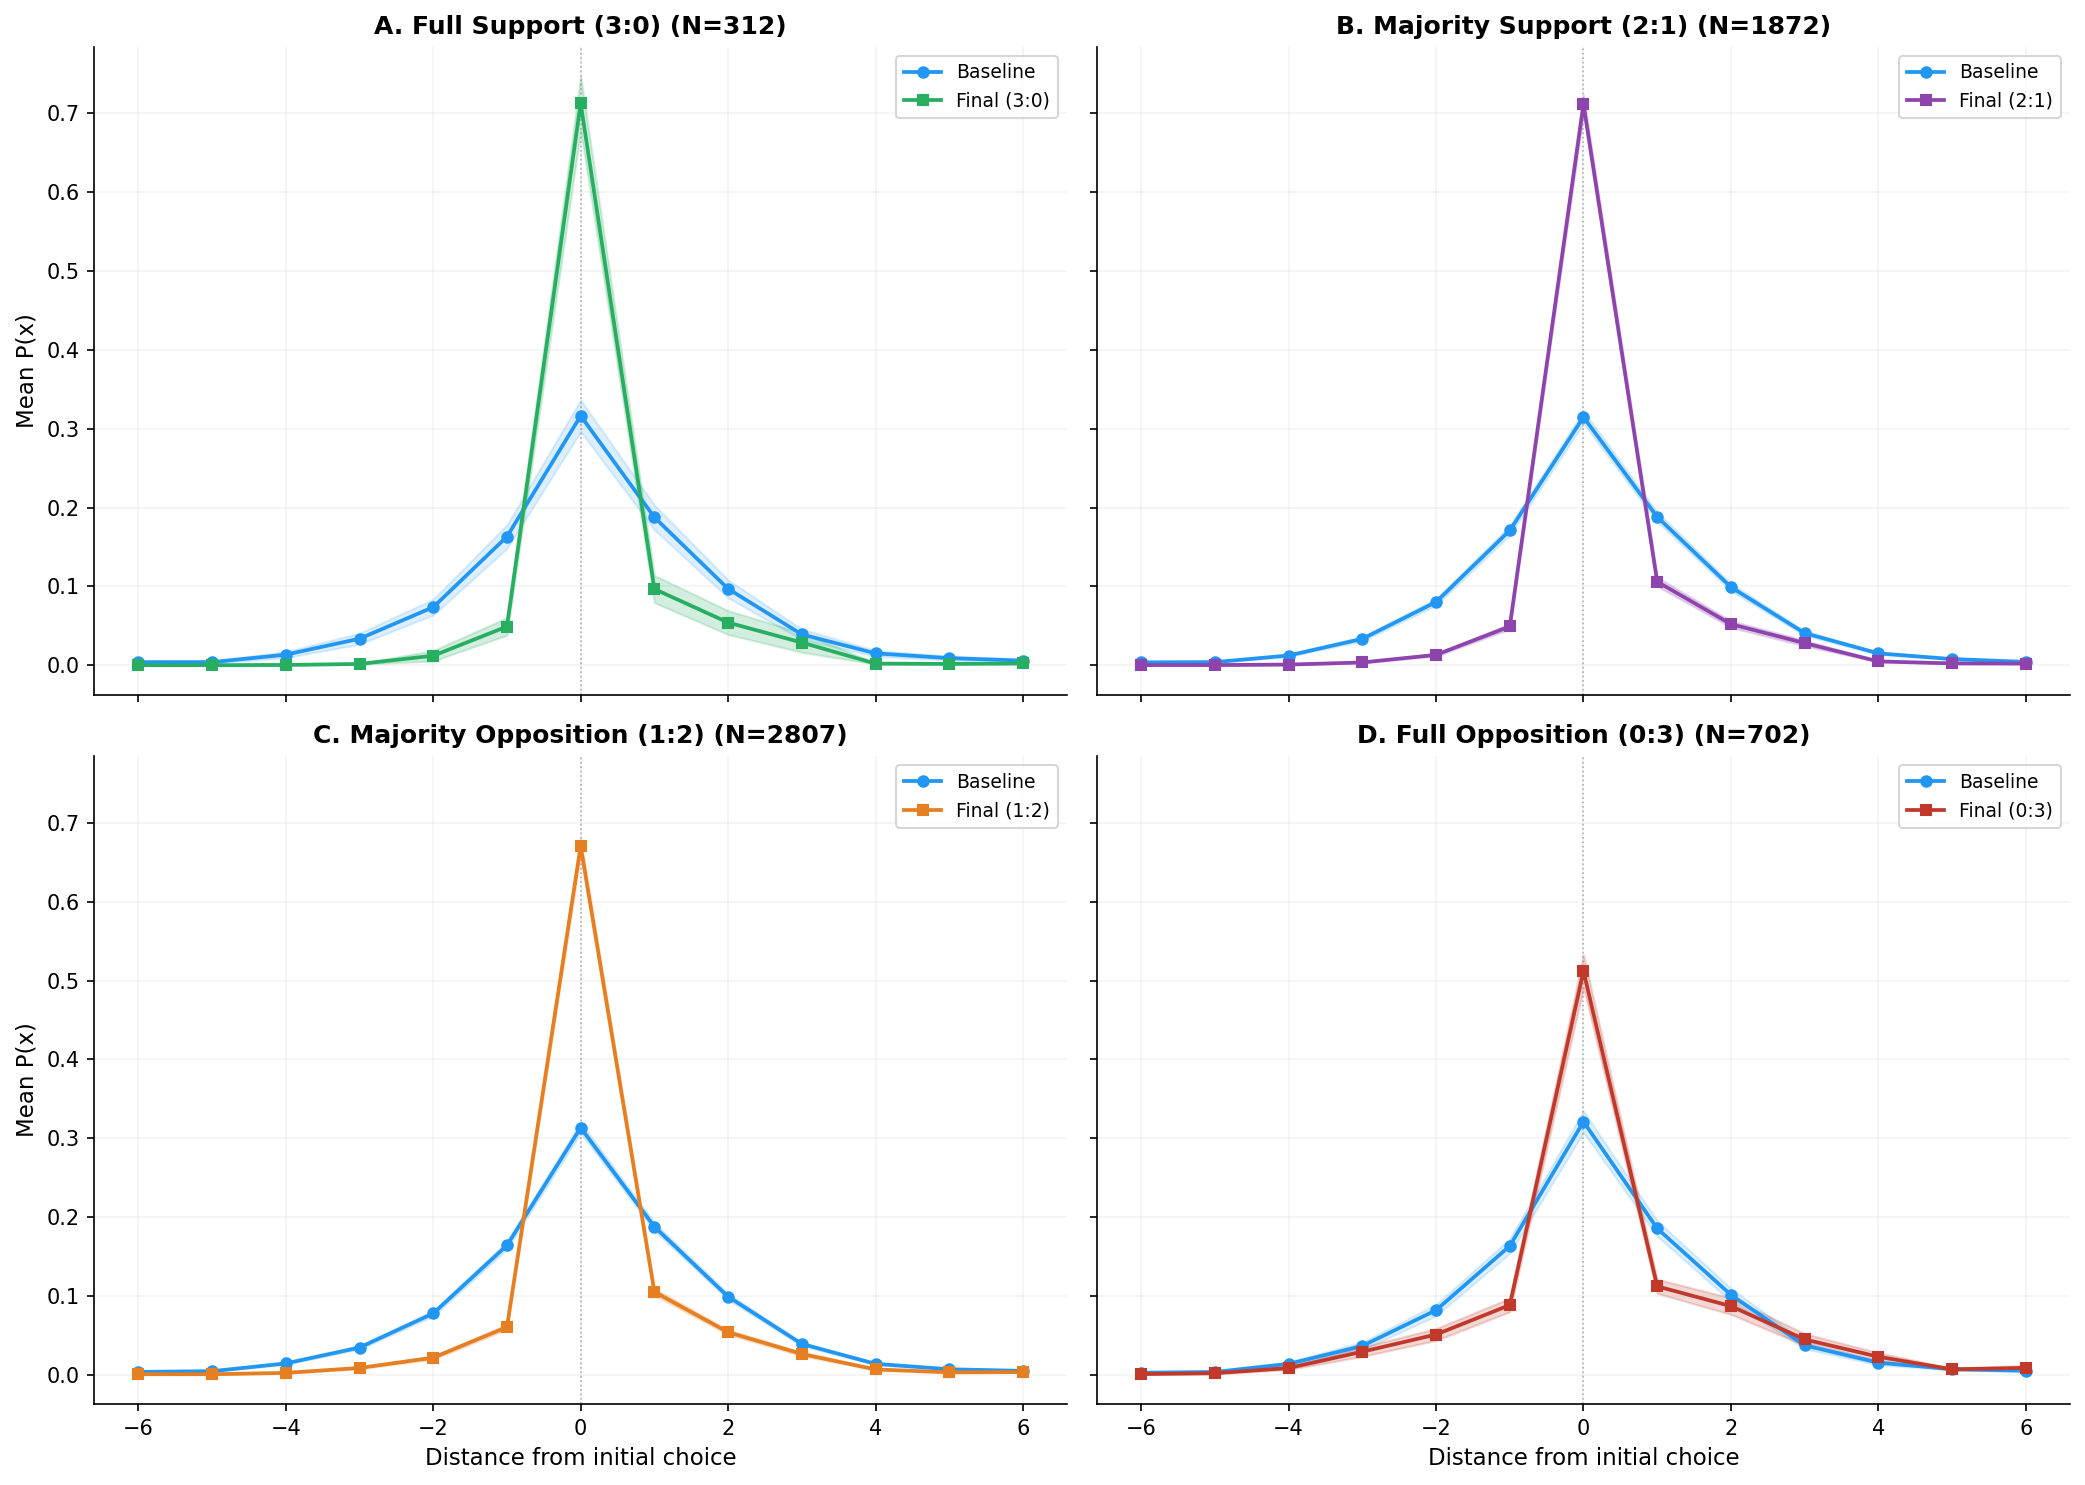

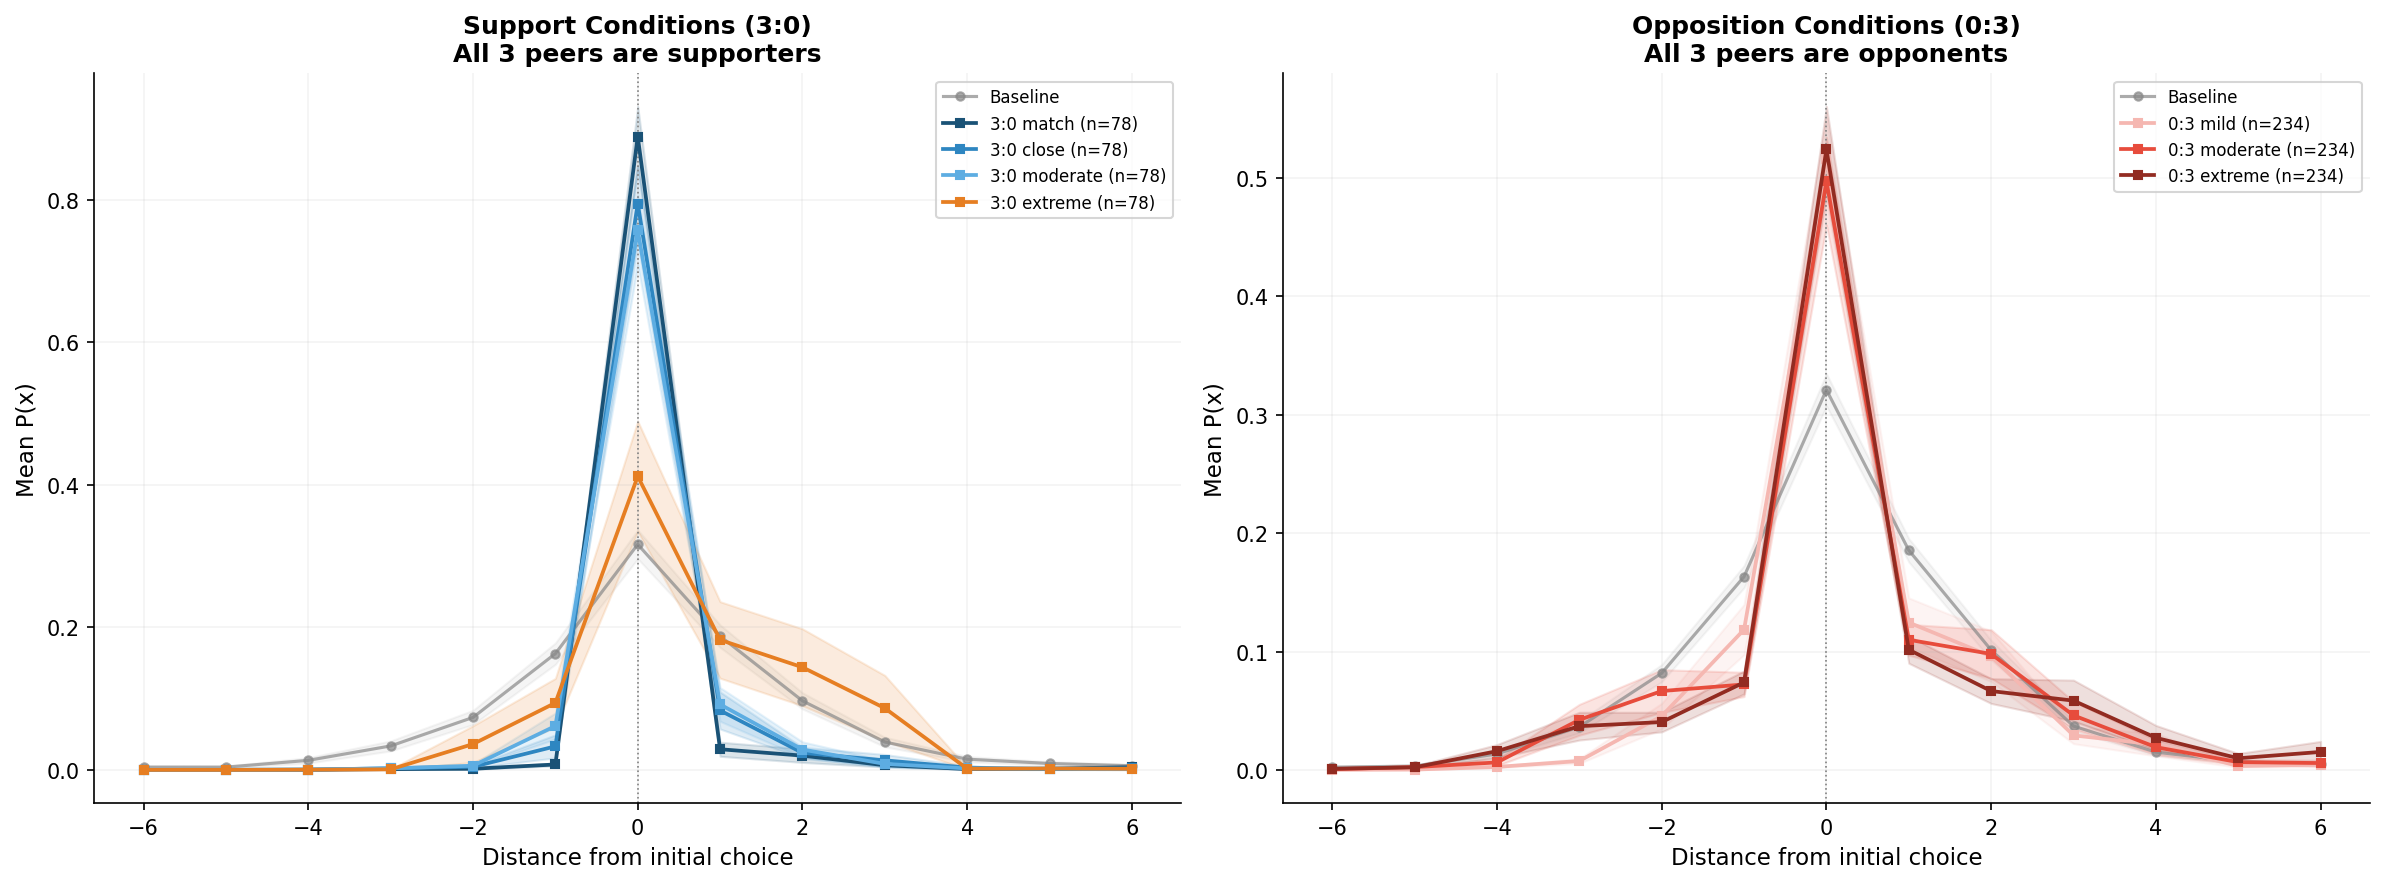

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10, "axes.labelsize": 11, "axes.titlesize": 12,
    "figure.dpi": 150, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
})

# ── Load 4-agent data ──
with open("/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study3/outputs/study3_deepseek/transcripts.jsonl") as f:
    rows = [json.loads(line) for line in f if line.strip()]

a1_base = {}; a1_final = {}
for r in rows:
    if r['agent'] != 'A1': continue
    key = (r['qid'], r['condition'])
    if r['round'] == 0: a1_base[key] = r
    elif r['round'] == 1: a1_final[key] = r

def get_dist(probs_dict):
    d = np.array([float(probs_dict.get(str(i), 0) or 0) for i in range(1, 8)])
    return d / d.sum() if d.sum() > 0 else d

def reindex(dist, base_choice):
    result = {}
    for idx, p in enumerate(dist):
        result[idx + 1 - base_choice] = result.get(idx + 1 - base_choice, 0) + p
    return result

def aggregate(dist_list, x_range=range(-6, 7)):
    accum = {d: [] for d in x_range}
    for dist in dist_list:
        for d in x_range:
            accum[d].append(dist.get(d, 0))
    means = np.array([np.mean(accum[d]) for d in x_range])
    cis = np.array([1.96 * np.std(accum[d], ddof=1) / np.sqrt(len(accum[d]))
                    if len(accum[d]) > 1 else 0 for d in x_range])
    return means, cis

# Collect by ratio and by unanimous condition
ratios_meta = {
    '3:0': ('Full Support (3:0)', '#27ae60'),
    '2:1': ('Majority Support (2:1)', '#8e44ad'),
    '1:2': ('Majority Opposition (1:2)', '#e67e22'),
    '0:3': ('Full Opposition (0:3)', '#c0392b'),
}
cond_meta = {
    'sup3_match': ('3:0 match', '#1a5276'),
    'sup3_close': ('3:0 close', '#2e86c1'),
    'sup3_moderate': ('3:0 moderate', '#5dade2'),
    'sup3_extreme': ('3:0 extreme', '#e67e22'),
    'opp3_mild': ('0:3 mild', '#f5b7b1'),
    'opp3_moderate': ('0:3 moderate', '#e74c3c'),
    'opp3_extreme': ('0:3 extreme', '#922b21'),
}

by_ratio = defaultdict(lambda: {'base': [], 'final': []})
by_cond = defaultdict(lambda: {'base': [], 'final': []})

for key in a1_base:
    if key not in a1_final: continue
    b, f = a1_base[key], a1_final[key]
    bp, fp = b.get('a1_dist_probs', {}), f.get('a1_dist_probs_final', {})
    if not bp or not fp: continue
    bc = b['parsed_choice']
    if bc is None: continue
    ba, fa = get_dist(bp), get_dist(fp)
    br, fr = reindex(ba, bc), reindex(fa, bc)
    ratio = f.get('ratio', '')
    if ratio in ratios_meta:
        by_ratio[ratio]['base'].append(br)
        by_ratio[ratio]['final'].append(fr)
    for prefix in cond_meta:
        if f['condition'].startswith(prefix):
            by_cond[prefix]['base'].append(br)
            by_cond[prefix]['final'].append(fr)

x = np.arange(-6, 7)

# ── Figure 1: 2x2 grid by ratio ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
for ax, ratio, pl in zip(axes.flat, ['3:0','2:1','1:2','0:3'], 'ABCD'):
    label, color = ratios_meta[ratio]
    bm, bci = aggregate(by_ratio[ratio]['base'])
    fm, fci = aggregate(by_ratio[ratio]['final'])
    n = len(by_ratio[ratio]['base'])
    ax.plot(x, bm, 'o-', color='#2196F3', markersize=5, linewidth=1.8, label='Baseline', zorder=3)
    ax.fill_between(x, bm-bci, bm+bci, alpha=0.15, color='#2196F3')
    ax.plot(x, fm, 's-', color=color, markersize=5, linewidth=1.8, label=f'Final ({ratio})', zorder=3)
    ax.fill_between(x, fm-fci, fm+fci, alpha=0.20, color=color)
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_title(f'{pl}. {label} (N={n})', fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.15)
    if ax in axes[1]: ax.set_xlabel('Distance from initial choice')
    if ax in axes[:, 0]: ax.set_ylabel('Mean P(x)')
plt.tight_layout()
plt.savefig('deepseek_fig_dist_shift_by_ratio_4agents.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── Figure 2: Unanimous conditions (support vs opposition sub-panels) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Left: Support
ax = axes[0]
sup_keys = ['sup3_match','sup3_close','sup3_moderate','sup3_extreme']
all_sup_b = []; [all_sup_b.extend(by_cond[c]['base']) for c in sup_keys]
bm, bci = aggregate(all_sup_b)
ax.plot(x, bm, 'o-', color='#888', markersize=4, linewidth=1.5, label='Baseline', alpha=0.7)
ax.fill_between(x, bm-bci, bm+bci, alpha=0.08, color='gray')
for prefix in sup_keys:
    label, color = cond_meta[prefix]
    fm, fci = aggregate(by_cond[prefix]['final'])
    ax.plot(x, fm, 's-', color=color, markersize=4, linewidth=1.8,
            label=f'{label} (n={len(by_cond[prefix]["final"])})', zorder=3)
    ax.fill_between(x, fm-fci, fm+fci, alpha=0.15, color=color)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Distance from initial choice'); ax.set_ylabel('Mean P(x)')
ax.set_title('Support Conditions (3:0)\nAll 3 peers are supporters', fontweight='bold')
ax.legend(fontsize=8, loc='upper right'); ax.grid(True, alpha=0.15)
# Right: Opposition
ax = axes[1]
opp_keys = ['opp3_mild','opp3_moderate','opp3_extreme']
all_opp_b = []; [all_opp_b.extend(by_cond[c]['base']) for c in opp_keys]
bm, bci = aggregate(all_opp_b)
ax.plot(x, bm, 'o-', color='#888', markersize=4, linewidth=1.5, label='Baseline', alpha=0.7)
ax.fill_between(x, bm-bci, bm+bci, alpha=0.08, color='gray')
for prefix in opp_keys:
    label, color = cond_meta[prefix]
    fm, fci = aggregate(by_cond[prefix]['final'])
    ax.plot(x, fm, 's-', color=color, markersize=4, linewidth=1.8,
            label=f'{label} (n={len(by_cond[prefix]["final"])})', zorder=3)
    ax.fill_between(x, fm-fci, fm+fci, alpha=0.15, color=color)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Distance from initial choice'); ax.set_ylabel('Mean P(x)')
ax.set_title('Opposition Conditions (0:3)\nAll 3 peers are opponents', fontweight='bold')
ax.legend(fontsize=8, loc='upper right'); ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig('deepseek_fig_dist_shift_by_position_4agents.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


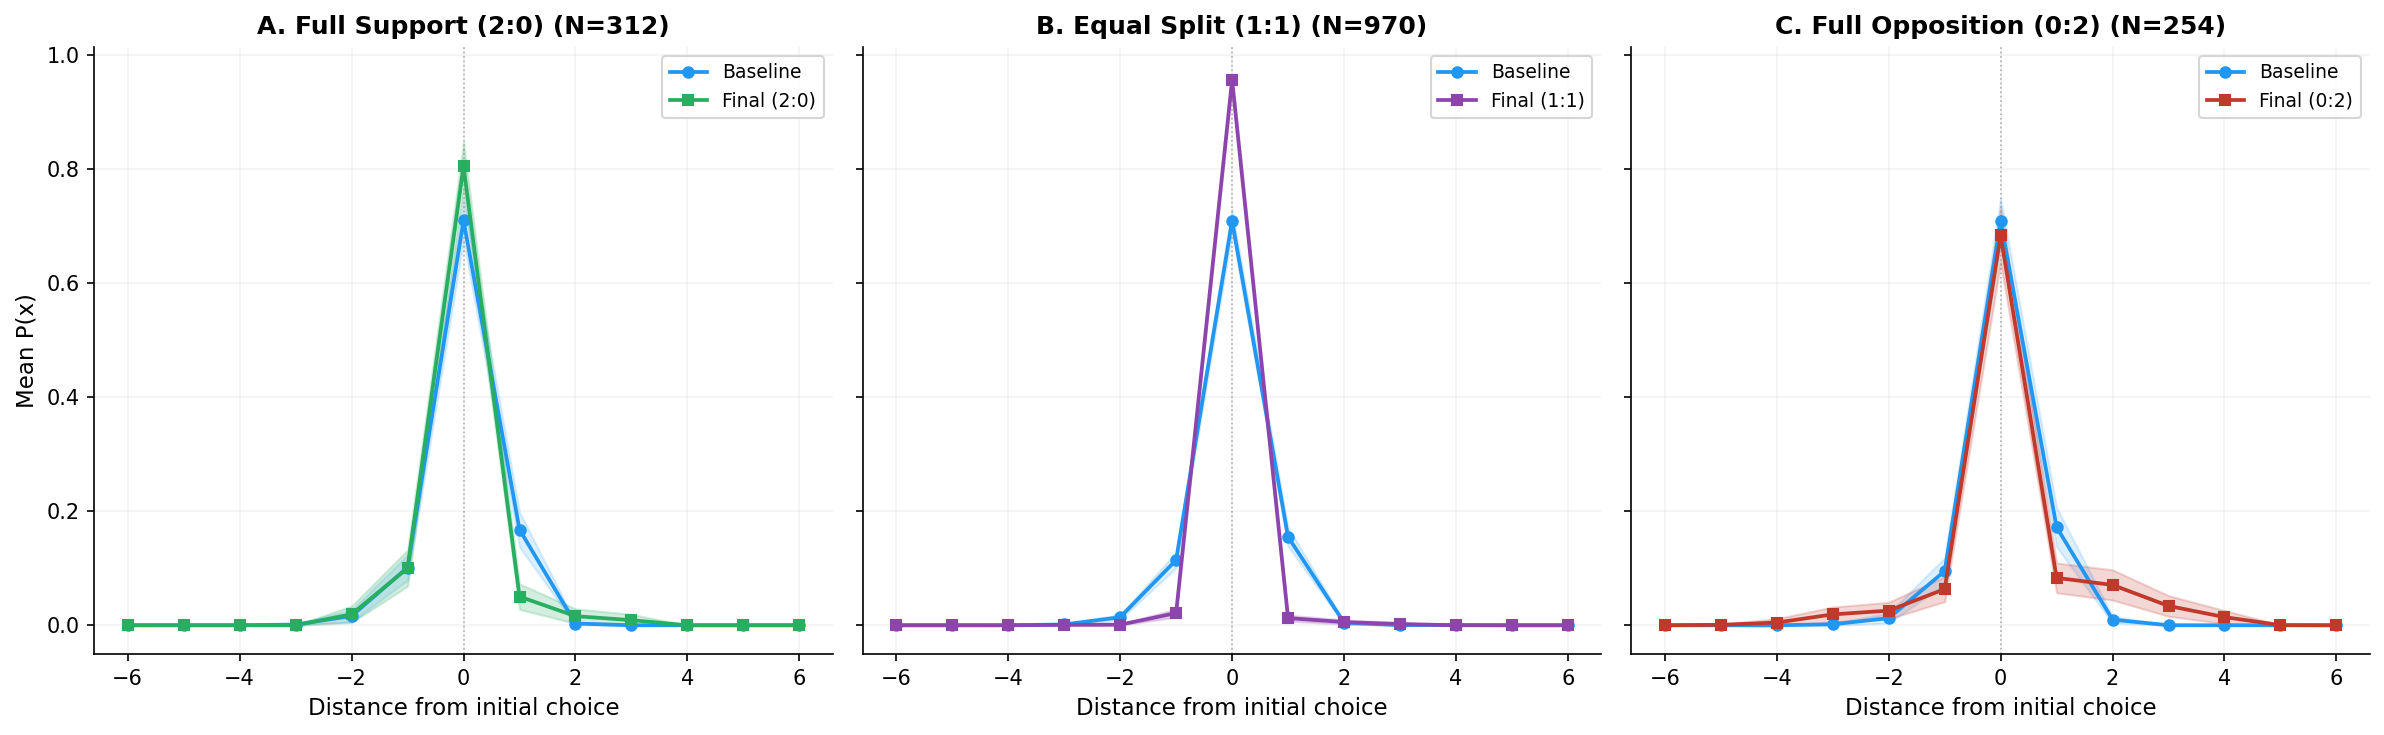

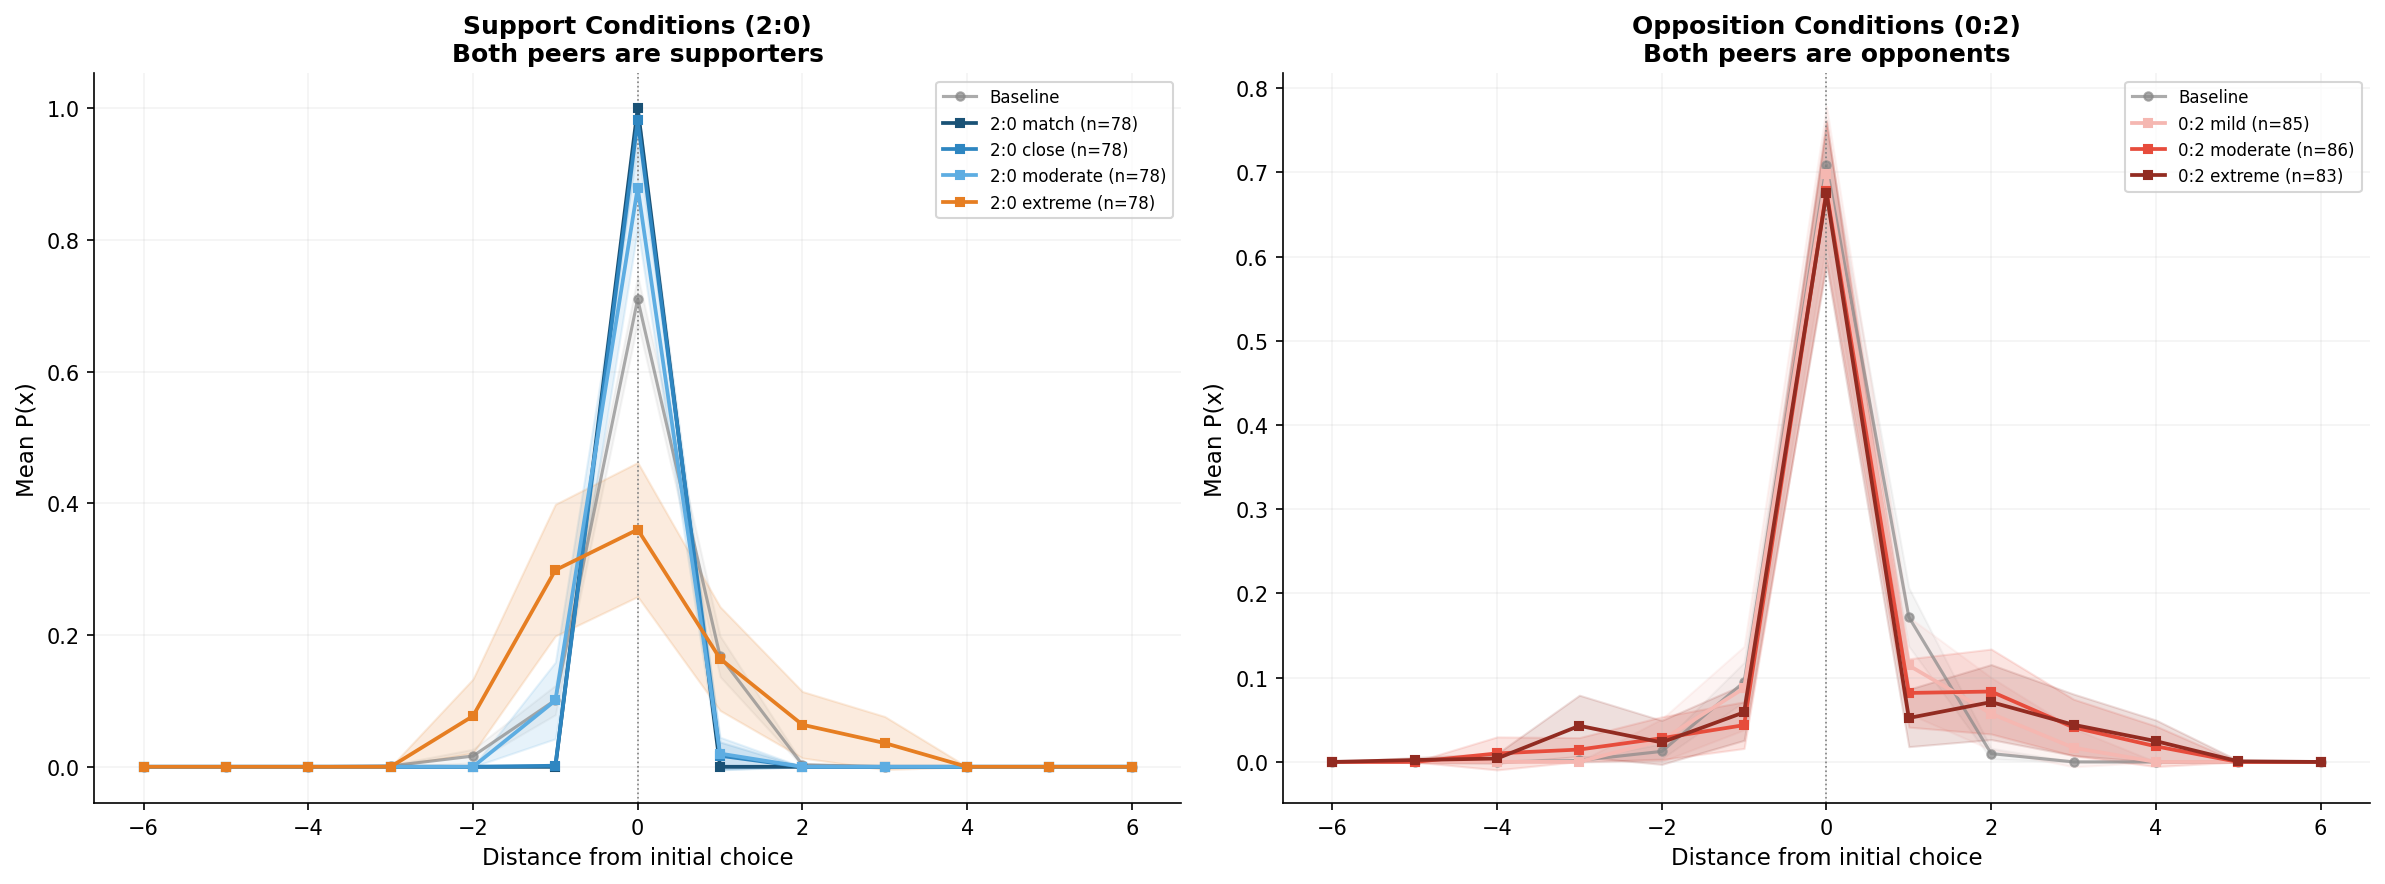

In [5]:
# ── Load 3-agent data ──
with open("/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study3/hydra_configs/outputs/study3_3agent_full_seed0/transcripts_2.jsonl") as f:
    rows3 = [json.loads(line) for line in f if line.strip()]

a1b3 = {}; a1f3 = {}
for r in rows3:
    if r['agent'] != 'A1': continue
    key = (r['qid'], r['condition'])
    if r['round'] == 0: a1b3[key] = r
    elif r['round'] == 1: a1f3[key] = r

ratios_3 = {
    '2:0': ('Full Support (2:0)', '#27ae60'),
    '1:1': ('Equal Split (1:1)', '#8e44ad'),
    '0:2': ('Full Opposition (0:2)', '#c0392b'),
}
cond_3 = {
    '3ag_sup2_match': ('2:0 match', '#1a5276'),
    '3ag_sup2_close': ('2:0 close', '#2e86c1'),
    '3ag_sup2_moderate': ('2:0 moderate', '#5dade2'),
    '3ag_sup2_extreme': ('2:0 extreme', '#e67e22'),
    '3ag_opp2_mild': ('0:2 mild', '#f5b7b1'),
    '3ag_opp2_moderate': ('0:2 moderate', '#e74c3c'),
    '3ag_opp2_extreme': ('0:2 extreme', '#922b21'),
}

by_ratio_3 = defaultdict(lambda: {'base': [], 'final': []})
by_cond_3 = defaultdict(lambda: {'base': [], 'final': []})

for key in a1b3:
    if key not in a1f3: continue
    b, f = a1b3[key], a1f3[key]
    bp, fp = b.get('a1_dist_probs', {}), f.get('a1_dist_probs_final', {})
    if not bp or not fp: continue
    bc = b['parsed_choice']
    if bc is None: continue
    ba, fa = get_dist(bp), get_dist(fp)
    br, fr = reindex(ba, bc), reindex(fa, bc)
    ratio = f.get('ratio', '')
    if ratio in ratios_3:
        by_ratio_3[ratio]['base'].append(br)
        by_ratio_3[ratio]['final'].append(fr)
    for prefix in cond_3:
        if f['condition'].startswith(prefix):
            by_cond_3[prefix]['base'].append(br)
            by_cond_3[prefix]['final'].append(fr)

# ── Figure 1: 1x3 grid by ratio ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, ratio, pl in zip(axes.flat, ['2:0','1:1','0:2'], 'ABC'):
    label, color = ratios_3[ratio]
    bm, bci = aggregate(by_ratio_3[ratio]['base'])
    fm, fci = aggregate(by_ratio_3[ratio]['final'])
    n = len(by_ratio_3[ratio]['base'])
    ax.plot(x, bm, 'o-', color='#2196F3', markersize=5, linewidth=1.8, label='Baseline', zorder=3)
    ax.fill_between(x, bm-bci, bm+bci, alpha=0.15, color='#2196F3')
    ax.plot(x, fm, 's-', color=color, markersize=5, linewidth=1.8, label=f'Final ({ratio})', zorder=3)
    ax.fill_between(x, fm-fci, fm+fci, alpha=0.20, color=color)
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_title(f'{pl}. {label} (N={n})', fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.15)
    ax.set_xlabel('Distance from initial choice')
    if ax == axes[0]: ax.set_ylabel('Mean P(x)')
plt.tight_layout()
plt.savefig('fig_dist_shift_by_ratio_3agents.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# ── Figure 2: Unanimous conditions (support vs opposition) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Left: Support
ax = axes[0]
sup_keys_3 = ['3ag_sup2_match','3ag_sup2_close','3ag_sup2_moderate','3ag_sup2_extreme']
all_sb = []; [all_sb.extend(by_cond_3[c]['base']) for c in sup_keys_3 if c in by_cond_3]
bm, bci = aggregate(all_sb)
ax.plot(x, bm, 'o-', color='#888', markersize=4, linewidth=1.5, label='Baseline', alpha=0.7)
ax.fill_between(x, bm-bci, bm+bci, alpha=0.08, color='gray')
for prefix in sup_keys_3:
    if prefix not in by_cond_3 or not by_cond_3[prefix]['final']: continue
    label, color = cond_3[prefix]
    fm, fci = aggregate(by_cond_3[prefix]['final'])
    ax.plot(x, fm, 's-', color=color, markersize=4, linewidth=1.8,
            label=f'{label} (n={len(by_cond_3[prefix]["final"])})', zorder=3)
    ax.fill_between(x, fm-fci, fm+fci, alpha=0.15, color=color)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Distance from initial choice'); ax.set_ylabel('Mean P(x)')
ax.set_title('Support Conditions (2:0)\nBoth peers are supporters', fontweight='bold')
ax.legend(fontsize=8, loc='upper right'); ax.grid(True, alpha=0.15)
# Right: Opposition
ax = axes[1]
opp_keys_3 = ['3ag_opp2_mild','3ag_opp2_moderate','3ag_opp2_extreme']
all_ob = []; [all_ob.extend(by_cond_3[c]['base']) for c in opp_keys_3 if c in by_cond_3]
if all_ob:
    bm, bci = aggregate(all_ob)
    ax.plot(x, bm, 'o-', color='#888', markersize=4, linewidth=1.5, label='Baseline', alpha=0.7)
    ax.fill_between(x, bm-bci, bm+bci, alpha=0.08, color='gray')
for prefix in opp_keys_3:
    if prefix not in by_cond_3 or not by_cond_3[prefix]['final']: continue
    label, color = cond_3[prefix]
    fm, fci = aggregate(by_cond_3[prefix]['final'])
    ax.plot(x, fm, 's-', color=color, markersize=4, linewidth=1.8,
            label=f'{label} (n={len(by_cond_3[prefix]["final"])})', zorder=3)
    ax.fill_between(x, fm-fci, fm+fci, alpha=0.15, color=color)
ax.axvline(0, color='gray', linestyle=':', linewidth=0.8)
ax.set_xlabel('Distance from initial choice'); ax.set_ylabel('Mean P(x)')
ax.set_title('Opposition Conditions (0:2)\nBoth peers are opponents', fontweight='bold')
ax.legend(fontsize=8, loc='upper right'); ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('fig_dist_shift_by_position_3agents.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
